# Taller: Análisis de Instagram con Apify API + Gemini  
Autor: (tu nombre)  
Fecha de generación: 2025-05-21


**Objetivos**

1. Obtener datos públicos de Instagram usando el actor **`apify/instagram-api-scraper`**.  
2. Limpiar y pre‑procesar captions e información de posts.  
3. Clasificar sentimiento de captions con la API de Google Generative AI (Gemini).  
4. Extraer temas dominantes con LDA y nombrarlos con Gemini.  
5. Segmentar autores o posts según métricas de engagement.  
6. Diseñar una micro‑campaña basada en los insights descubiertos.


In [ ]:
!wget https://github.com/javierherrera1996/IntroMarketingAnalytics/raw/refs/heads/main/TercerCorte/instagram_posts.csv

--2025-11-20 00:14:47--  https://github.com/javierherrera1996/IntroMarketingAnalytics/raw/refs/heads/main/TercerCorte/instagram_posts.csv
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/javierherrera1996/IntroMarketingAnalytics/refs/heads/main/TercerCorte/instagram_posts.csv [following]
--2025-11-20 00:14:47--  https://raw.githubusercontent.com/javierherrera1996/IntroMarketingAnalytics/refs/heads/main/TercerCorte/instagram_posts.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18361753 (18M) [text/plain]
Saving to: ‘instagram_posts.csv’

instagram_posts.csv 100%[===================>]  17.51M 

In [ ]:
import pandas as pd

In [ ]:
!pip install -qU requests pandas google-generativeai nltk seaborn wordcloud scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 65.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [ ]:
df = pd.read_csv('instagram_posts.csv')
df.head()

,inputUrl,id,username,url,fullName,biography,externalUrls,externalUrl,externalUrlShimmed,followersCount,...,musicInfo.artist_name,musicInfo.song_name,musicInfo.uses_original_audio,musicInfo.should_mute_audio,musicInfo.should_mute_audio_reason,musicInfo.audio_id,locationName,locationId,paidPartnership,sponsors
0,https://www.instagram.com/f1/,3637646598679593202,f1,https://www.instagram.com/p/DJ7hE70tIDy/,FORMULA 1®,It's All To Drive For!\n \nThis story can only...,"[{'title': 'Overtake of the month vote', 'lynx...",https://f1.com/Overtake,https://l.instagram.com/?u=https%3A%2F%2Ff1.co...,34614194,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.instagram.com/f1/,3637494954817152582,f1,https://www.instagram.com/p/DJ6-mOeJuZG/,FORMULA 1®,It's All To Drive For!\n \nThis story can only...,"[{'title': 'Overtake of the month vote', 'lynx...",https://f1.com/Overtake,https://l.instagram.com/?u=https%3A%2F%2Ff1.co...,34614194,...,f1movie,Original audio,True,False,NaN,1.403914e+15,NaN,NaN,NaN,NaN
2,https://www.instagram.com/f1/,3637535605467005779,f1,https://www.instagram.com/p/DJ7H1xVskNT/,FORMULA 1®,It's All To Drive For!\n \nThis story can only...,"[{'title': 'Overtake of the month vote', 'lynx...",https://f1.com/Overtake,https://l.instagram.com/?u=https%3A%2F%2Ff1.co...,34614194,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,https://www.instagram.com/f1/,3635278159597499148,f1,https://www.instagram.com/p/DJzGjnCi3MM/,FORMULA 1®,It's All To Drive For!\n \nThis story can only...,"[{'title': 'Overtake of the month vote', 'lynx...",https://f1.com/Overtake,https://l.instagram.com/?u=https%3A%2F%2Ff1.co...,34614194,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,https://www.instagram.com/f1/,3637456706674459999,f1,https://www.instagram.com/p/DJ615pHMYVf/,FORMULA 1®,It's All To Drive For!\n \nThis story can only...,"[{'title': 'Overtake of the month vote', 'lynx...",https://f1.com/Overtake,https://l.instagram.com/?u=https%3A%2F%2Ff1.co...,34614194,...,NaN,NaN,NaN,NaN,NaN,NaN,Monaco,16366456.0,NaN,NaN


In [ ]:
df.columns

Index(['inputUrl', 'id', 'username', 'url', 'fullName', 'biography',
       'externalUrls', 'externalUrl', 'externalUrlShimmed', 'followersCount',
       'followsCount', 'hasChannel', 'highlightReelCount', 'isBusinessAccount',
       'joinedRecently', 'businessCategoryName', 'private', 'verified',
       'profilePicUrl', 'profilePicUrlHD', 'igtvVideoCount', 'relatedProfiles',
       'latestIgtvVideos', 'postsCount', 'fbid', 'type', 'shortCode',
       'caption', 'hashtags', 'mentions', 'commentsCount', 'firstComment',
       'latestComments', 'dimensionsHeight', 'dimensionsWidth', 'displayUrl',
       'images', 'alt', 'likesCount', 'timestamp', 'childPosts',
       'ownerFullName', 'ownerUsername', 'ownerId', 'isSponsored',
       'taggedUsers', 'coauthorProducers', 'isCommentsDisabled', 'videoUrl',
       'videoViewCount', 'videoPlayCount', 'productType', 'videoDuration',
       'isPinned', 'musicInfo.artist_name', 'musicInfo.song_name',
       'musicInfo.uses_original_audio', 'musicI

In [ ]:
df['timestamp']

,timestamp
0,2025-05-21T21:01:28.000Z
1,2025-05-21T16:00:00.000Z
2,2025-05-21T17:20:56.000Z
3,2025-05-18T14:35:48.000Z
4,2025-05-21T14:44:11.000Z
...,...
195,2025-05-05T10:11:05.000Z
196,2025-05-05T09:32:05.000Z
197,2025-05-05T11:02:12.000Z
198,2025-05-05T11:04:41.000Z



### 🔍 Preguntas – Sección 1 (Exploración)

1. ¿Cuántos posts hay en total?  
2. ¿Qué tipos de contenido (imagen, vídeo, carrusel) predominan?  
3. ¿Cuál es el rango de fechas cubierto por los posts?  
4. ¿Qué post obtuvo más 'likes' y cuál crees que es la razón?


In [ ]:
df.shape

(200, 64)

In [ ]:
df['type'].value_counts()

,count
type,
Video,86
Sidecar,83
Image,31


In [ ]:
from datetime import datetime
datetime.fromtimestamp(int())

datetime.datetime(1970, 1, 1, 0, 0)

In [ ]:
df["date"] = pd.to_datetime(df["timestamp"])

In [ ]:
df["date"].max()

Timestamp('2025-05-21 21:01:28+0000', tz='UTC')

In [ ]:
df["date"].min()

Timestamp('2025-05-05 00:59:11+0000', tz='UTC')

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
df['likesCount'].sort_values(ascending=False)

,likesCount
138,1927755
184,1886670
175,1812728
176,1734008
3,1590803
...,...
57,98256
125,98127
55,84260
1,83824


In [ ]:
df[df["likesCount"]==df["likesCount"].max()]

,inputUrl,id,username,url,fullName,biography,externalUrls,externalUrl,externalUrlShimmed,followersCount,followsCount,hasChannel,highlightReelCount,isBusinessAccount,joinedRecently,businessCategoryName,private,verified,profilePicUrl,profilePicUrlHD,igtvVideoCount,relatedProfiles,latestIgtvVideos,postsCount,fbid,type,shortCode,caption,hashtags,mentions,commentsCount,firstComment,latestComments,dimensionsHeight,dimensionsWidth,displayUrl,images,alt,likesCount,timestamp,childPosts,ownerFullName,ownerUsername,ownerId,isSponsored,taggedUsers,coauthorProducers,isCommentsDisabled,videoUrl,videoViewCount,videoPlayCount,productType,videoDuration,isPinned,musicInfo.artist_name,musicInfo.song_name,musicInfo.uses_original_audio,musicInfo.should_mute_audio,musicInfo.should_mute_audio_reason,musicInfo.audio_id,locationName,locationId,paidPartnership,sponsors,date,caption_clean,caption_limpio
138,https://www.instagram.com/f1/,3630879158915563525,f1,https://www.instagram.com/p/DJjeVuZiAAF/,FORMULA 1®,It's All To Drive For!\n \nThis story can only...,"[{'title': 'Overtake of the month vote', 'lynx...",https://f1.com/Overtake,https://l.instagram.com/?u=https%3A%2F%2Ff1.co...,34614194,102,False,4,True,False,NaN,False,True,https://instagram.fdet3-1.fna.fbcdn.net/v/t51....,https://instagram.fdet3-1.fna.fbcdn.net/v/t51....,389,"[{'id': '43904777', 'full_name': 'Max Verstapp...","[{'type': 'Video', 'shortCode': 'C7RkVkkI0CO',...",27715,17841400608786450,Image,DJjeVuZiAAF,Let’s ride. \n\n#F1TheMovie only in theaters J...,"['F1TheMovie', 'F1', 'Formula1']",[],2688,🔥🔥,"[{'id': '17882814276282508', 'text': '🔥🔥', 'ow...",1350,1080,https://scontent-mia3-1.cdninstagram.com/v/t51...,[],"Photo shared by FORMULA 1® on May 12, 2025 tag...",1927755,2025-05-12T12:55:46.000Z,[],FORMULA 1®,f1,1692820292,False,"[{'full_name': 'Warner Bros.', 'id': '18180040...","[{'id': '184912812', 'is_verified': True, 'pro...",False,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-12 12:55:46+00:00,let’s ride f1themovie only in theaters june 27...,let’s ride f1themovie only in theaters june 27...



## 🧹 Sección 2 (Limpieza)

Explica por qué es importante limpiar y normalizar el texto de los captions.  
Enumera tres tipos de “ruido” que removerás (URLs, emojis, menciones, etc.) y da un ejemplo de cada uno.


In [ ]:
import re, nltk, string
nltk.download('stopwords')
from nltk.corpus import stopwords

def clean_caption(text):
    text = text.lower()
    text = re.sub(r"http\S+", " ", text)        # URLs
    text = re.sub(r"@[\w_]+", " ", text)        # Menciones
    text = re.sub(r"[#]", " ", text)             # Hashtags (opcional: conservar)
    text = re.sub(r"[{}]".format(string.punctuation), " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['caption_clean'] = df['caption'].fillna("").apply(clean_caption)
df[['caption', 'caption_clean']].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,caption,caption_clean
0,It certainly got the drivers’ seal of approval...,it certainly got the drivers’ seal of approval...
1,It’s go time! Get your tickets for #F1TheMovie...,it’s go time get your tickets for f1themovie n...
2,Rolling up to #F1TheMovie! 🤩 Our drivers have ...,rolling up to f1themovie 🤩 our drivers have ar...
3,A DOMINANT WIN FROM MAX VERSTAPPEN!! 👏\n\nThe ...,a dominant win from max verstappen 👏 the reign...
4,Monte Carlo ready 😍🇲🇨\n\n#McLaren #M7AReborn #F1,monte carlo ready 😍🇲🇨 mclaren m7areborn f1


In [ ]:
df['caption_clean'].head()

,caption_clean
0,it certainly got the drivers’ seal of approval...
1,it’s go time get your tickets for f1themovie n...
2,rolling up to f1themovie 🤩 our drivers have ar...
3,a dominant win from max verstappen 👏 the reign...
4,monte carlo ready 😍🇲🇨 mclaren m7areborn f1


In [ ]:
df["caption_limpio"] = df["caption"].apply(clean_caption)


## 😊 Sección 3 (Sentimiento)

7. Presenta la distribución global de sentimientos y comenta.  
8. ¿Qué tipo de contenido genera mayor proporción de sentimientos positivos y negativos?  
9. Elige un pico de sentimiento negativo y analiza el contexto con un ejemplo de post.


In [ ]:
import os
os.environ["OPENAI_API_KEY"] =
from openai import OpenAI

client = OpenAI()

In [ ]:
from openai import OpenAI

client = OpenAI()


In [ ]:
def call_llm(prompt):
  response = client.responses.create(
  model="gpt-4o-mini",
  input=prompt
)
  return response.output_text



In [ ]:
call_llm("que día es hoy?")

'Hoy es 29 de octubre de 2023. ¿En qué más puedo ayudarte?'

In [ ]:
import time

def classify_sentiment(text):
    prompt = (f"Clasifica el sentimiento del siguiente caption de Instagram como "
              f"'positivo', 'neutral' o 'negativo' siempre en minuscula. Solo responde con una palabra.\n\nCaption:\n{text}")
    time.sleep(2)  # Evitar rate limits
    return call_llm(prompt)

# ⚠️ Usa una muestra para no exceder la cuota de la API
sample = df.sample(10, replace = True ,random_state=42)
sample['sentimiento'] = sample['caption_clean'].apply(classify_sentiment)


In [ ]:
sample['sentimiento'].value_counts()


,count
sentimiento,
positivo,8
neutral,2


<Axes: xlabel='sentimiento'>

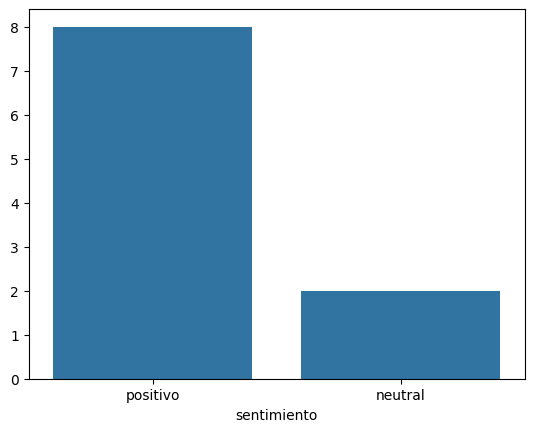

In [ ]:
import seaborn as sns
sns.barplot(x=sample['sentimiento'].value_counts().index, y=sample['sentimiento'].value_counts().values)



## 🗂 Sección 4 (Temas)
9. Haga lo mismo con sentidimiento con tipo de contenido y tema
10. Lista los nombres de los temas generados. ¿Alguno es inesperado?  
11. Con un heatmap *tipo de contenido × tema*, indica qué tema es “propiedad” de cada formato.  
12. Para el tema dominante, proporciona dos insights accionables.


In [ ]:
import time

def classify_sentiment(text):
    prompt = (f"Clasifica el tipo de contenido del siguiente caption de Instagram como "
              f"'resultados_estadisticas', 'entre_bastidores' o 'tecnologia_vehiculos' siempre en minuscula. Solo responde con una palabra.\n\nCaption:\n{text}")
    time.sleep(2)  # Evitar rate limits
    return call_llm(prompt)

# ⚠️ Usa una muestra para no exceder la cuota de la API
sample = df.sample(10, replace = True ,random_state=42)
sample['topic'] = sample['caption_clean'].apply(classify_sentiment)




In [ ]:
sample['topic'].value_counts()

,count
topic,
entre_bastidores,7
resultados_estadisticas,3


In [ ]:
pd.crosstab(sample['topic'], sample['type'])

type,Image,Sidecar,Video
topic,,,
entre_bastidores,1,1,5
resultados_estadisticas,1,2,0


<Axes: xlabel='type', ylabel='topic'>

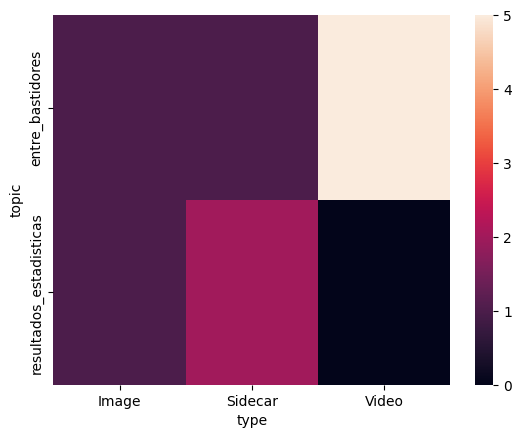

In [ ]:
sns.heatmap(pd.crosstab(sample['topic'], sample['type']))


## 👥 Sección 5 (Segmentación)

13. Describe cada cluster en una frase (actividad y tono).  
14. ¿Qué segmento priorizarías para viralizar un mensaje y por qué?  
15. Propón una acción de engagement distinta para cada segmento.


In [ ]:
call_llm("""Describe cada cluster en una frase (actividad y tono). damelo como una lista de python.topic entre_bastidores resultados_estadisticas
type
Image 1 1
Sidecar 1 2
Video 5 0
""")

'Aquí tienes una lista de Python que describe cada cluster con su actividad y tono:\n\n```python\nclusters = [\n    {"tipo": "Image", "actividad": "Imágenes visuales", "tono": "Informativo"},\n    {"tipo": "Sidecar", "actividad": "Contenido adicional interactivo", "tono": "Engaging"},\n    {"tipo": "Video", "actividad": "Videos explicativos", "tono": "Educativo"}\n]\n```'


## 📝 Sección 6 (Micro‑campaña)

16. Presenta tus tres captions generados.  
17. Justifica  
&nbsp;&nbsp;a) Tema elegido.  
&nbsp;&nbsp;b) Tono y horario óptimos.  
18. Define un KPI de éxito y la meta para la campaña.


In [ ]:
lista_tonos =  {"tipo": "Image", "actividad": "Imágenes visuales", "tono": "Informativo"},    {"tipo": "Sidecar", "actividad": "Contenido adicional interactivo", "tono": "Engaging"},  {"tipo": "Video", "actividad": "Videos explicativos", "tono": "Educativo"}

In [ ]:
def generar_caption(topic,tone):
    prompt = (f"Actúa como community manager. Crea un caption de máximo 220 caracteres "
              f"sobre el tema '{topic}'. Tono {tone}. No incluyas hashtags ni menciones.")
    return call_llm(prompt)

for lista in lista_tonos:
  print (generar_caption(lista['actividad'], lista['tono']))
  print ("_______________")


Las imágenes visuales son poderosas herramientas de comunicación que capturan la atención y transmiten emociones. Utilizar elementos visuales en tus mensajes puede aumentar la comprensión y el impacto de tu contenido. ¡Inspírate!
_______________
¡Descubre la magia del contenido adicional interactivo! Sumérgete en experiencias únicas que transforman lo habitual en extraordinario. ¿Estás listo para interactuar y llevar tu experiencia al siguiente nivel? ✨
_______________
Los videos explicativos son herramientas poderosas que simplifican conceptos complejos. Al combinar imágenes y narración, facilitan el aprendizaje y retención. ¿Listo para transformar tu manera de entender el mundo?
_______________



### 📦 Exporta y entrega

1. Ejecuta todo el notebook (**Runtime → Run all**).  
2. Descarga el notebook (File → Download → .ipynb) y el memo en *PDF* o *Markdown*.  
3. Sube ambos archivos a la plataforma de la clase antes de la fecha establecida.
